In [4]:
import sys
# sys.path.append('/home/cmu/github/LPBFDiffusionSR/datasets')
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
from torch.utils import data
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
from skimage.metrics import structural_similarity as ssim_id

import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 
# print(os.listdir('.'))
# from datasets.dataset import TemperatureXZDataset
from runners.train_diffusion import forwardpass
from analysis_functions import predict_lrenc, predict_mobilenet, predict_ddim_diffusion,predict_modified_diffusion, predict_diffusion, plot_images, get_profile, load_mobilenet, load_encoder, load_diffusion, PSNR, SSIM, multifield_plot_images
from models.diffusion_model import Unet
from models.lr_encoder_model import rrdbnet_encoder as rrdbnet_x4


In [5]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)

In [21]:
device = 'cuda'

def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a

def predict_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dataset, seq, factor = 2, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape)< 4:

        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = factor)
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float(), factor = factor)
    shape=hr.shape
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to('cuda')
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a

def predict_ddpm_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape)< 4:

        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = dataset.factor)
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float(), factor = dataset.factor)
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        xs = [x]
        x0_preds = []
        betas = b
        for i, j in zip(reversed(seq), reversed(seq_next)):

            noise = torch.randn_like(x)


            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(betas, t.long())
            atm1 = compute_alpha(betas, next_t.long())
            beta_t = 1 - at / atm1
            x = xs[-1].to('cuda')

            et =model(x, t, x_e)
            # e = output

            x0_from_e = (1.0 / at).sqrt() * x - (1.0 / at - 1).sqrt() * et
            # x0_from_e = torch.clamp(x0_from_e, -1, 1)
            x0_preds.append(x0_from_e.to('cpu'))
            mean_eps = (
                (atm1.sqrt() * beta_t) * x0_from_e + ((1 - beta_t).sqrt() * (1 - atm1)) * x
            ) / (1.0 - at)

            mean = mean_eps
            # noise = torch.randn_like(x)
            mask = 1 - (t == 0).float()
            mask = mask.view(-1, 1, 1, 1)
            logvar = beta_t.log()
            sample = mean + mask * torch.exp(0.5 * logvar) * noise
            # sample = mean + mask * c1 * noise

            # print(torch.sum(sample-xt_next))
            xs.append(sample.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b



In [26]:


def predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, encoding, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas

    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if encoding:
            # x_e = forwardpass(lr_enc, lr.to(device).float(), factor = train_dataset.factor)
        if len(lr.shape)< 4:
            x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = 2)
        else:
            x_e = forwardpass(lr_enc, lr.to(device).float(), factor = 2)
    else:
        x_e = upscaled_lr.to(device).float().repeat(1,1,1, 1)
    
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    # with torch.no_grad():
    #     n = img.size(0)
    #     seq_next = [-1] + list(seq[:-1])
    #     x0_preds = []
        
    #     x = torch.randn(shape, device=device)
    #     xs = [x]
    #     for i, j in zip(reversed(seq), reversed(seq_next)):
    #         t = (torch.ones(n) * i).to(x.device)
    #         next_t = (torch.ones(n) * j).to(x.device)
    #         at = compute_alpha(b, t.long())
    #         at_next = compute_alpha(b, next_t.long())
    #         xt = xs[-1].to('cuda')
    #         et = model(x, t, x_e)#model(xt, t)
    #         x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
    #         x0_preds.append(x0_t.to('cpu'))
    #         c1 = (
    #             kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
    #         )
    #         c2 = ((1 - at_next) - c1 ** 2).sqrt()
    #         xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
    #         xs.append(xt_next.to('cpu'))
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to('cuda')
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b



In [17]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_images(input, result, target, modeltype, split = 'train', timesteps = 200, title = '', timestep = None, save =False):
    
    result  = result
    scaling_factor = 1.5
    dpi = 150
    min_temp = 293
    max_temp = 5000
    method = 'Direct'
    # os.makedirs('lrenc_saved_figures', exist_ok = True)
    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    # plt.imshow(input.T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # clb = plt.colorbar()

    plt.figure(dpi = dpi)
    ax = plt.gca()
    if timestep is None:
        plt.title('[{} Data] Low Resolution, {}'.format(split, method), fontsize = 10)
    else:
        plt.title(r'[{} Data] Low Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')

    im = ax.imshow(input[:,input.shape[-1]//2:].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000,  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    if save:
        plt.savefig( title + 'input.png')
    else:
        plt.show()
    # plt.show()
    plt.clf()
    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    # plt.imshow((target).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # clb = plt.colorbar()
    # clb.ax.set_title(r'T$[K]$',fontsize=10)
    # frame_tick()
    # # plt.title('[{} Data] High Resolution'.format(split), fontsize = 10)
    # plt.title(r'[{} Data] High Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/target' + title + '.png')


    plt.figure(dpi = dpi)
    ax = plt.gca()
    if timestep is None:
        plt.title('[{} Data] High Resolution'.format(split), fontsize = 10)
    else:
        plt.title(r'[{} Data] High Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')

    im = ax.imshow(target[:,target.shape[-1]//2:].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000,  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()



    if save:
        plt.savefig( title + 'target.png')
    else:
        plt.show()

    # plt.show()
    plt.clf()

    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    # plt.imshow((result).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # clb = plt.colorbar()
    # clb.ax.set_title(r'T$[K]$',fontsize=10)
    # frame_tick()
    # # plt.title('[{} Data], {} Timesteps, {} Output'.format(split,str(timesteps), modeltype), fontsize = 10)
    # plt.title(r'[{} Data], {} Timesteps, {} Output, $i$ = {}'.format(split,str(timesteps), modeltype, str(timestep)), fontsize = 8)


    plt.figure(dpi = dpi)
    ax = plt.gca()
    if timestep is None:
        plt.title('[{} Data], {} Timesteps, {} Output'.format(split,str(timesteps), modeltype), fontsize = 10)
    else:
        plt.title(r'[{} Data], {} Timesteps, {} Output, $i$ = {}'.format(split,str(timesteps), modeltype, str(timestep)), fontsize = 8)
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')

    im = ax.imshow(result[:,result.shape[-1]//2:].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000,  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/result'+ title + '.png')
    if save:
        plt.savefig( title + 'result.png')
    else:
        plt.show()

    # plt.show()
    plt.clf()
    plt.close('all')

In [16]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def multifield_plot_images(input, result, target, modeltype, field_idx, field_key, split = 'train', timesteps = 200, title = '', timestep = None):
    
    result  = result
    scaling_factor = 1.5
    dpi = 90
    min_temp = 293
    max_temp = 5000
    method = 'Direct'

    # if timestep is None:
    #     plt.title('[{} Data] Low Resolution, {}'.format(split, method), fontsize = 10)
    # else:
    #     plt.title(r'[{} Data] Low Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
        
    axis_lim_min= {'vx': -30, 'vy':-30, 'vz':-30, 'temperature':293, 'pressure': 900000, 'liqlabel':0}
    axis_lim_max= {'vx': 30, 'vy':30, 'vz':30, 'temperature':5000, 'pressure': 4*1000000, 'liqlabel':1}
    titles= {'vx': r"$v_x$ [cm/s]", 'vy':r"$v_y$ [cm/s]", 'vz':r"$v_z$ [cm/s]", 'temperature':"T [K]", 'pressure': "P [Pa]", 'liqlabel':"Liquid Volume Fraction"}

    # os.makedirs('lrenc_saved_figures', exist_ok = True)
    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    # plt.imshow(input[field_idx].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # clb = plt.colorbar()
    # clb.ax.set_title(r'T$[K]$',fontsize=10)


    plt.figure(dpi = dpi)
    ax = plt.gca()
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    im = ax.imshow(input[field_idx][:,input.shape[-1]//4:3*input.shape[-1]//4].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)

    
    frame_tick()

    # plt.title('t = {} s, P = {} W, V = {} mm/s'.format(0.5*i/100, power, velocity))

    plt.savefig( title + 'input.png')

    # plt.show()
    plt.clf()
    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    # plt.imshow((target[field_idx]).T, cmap = 'jet', vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # # clb = plt.colorbar()
    # clb = plt.colorbar()
    # clb.ax.set_title(titles[field_key])


    plt.figure(dpi = dpi)
    ax = plt.gca()
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    im = ax.imshow(target[field_idx][:,target.shape[-1]//4:3*target.shape[-1]//4].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    # clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    # plt.title('[{} Data] High Resolution'.format(split), fontsize = 10)
    # plt.title(r'[{} Data] High Resolution, {}, $i$ = {}'.format(split, method, timestep), fontsize = 10)
    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/target' + title + '.png')
    plt.savefig( title + 'target.png')


    # plt.show()
    plt.clf()

    # plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    # plt.imshow((result[field_idx]).T, cmap = 'jet', vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    # plt.xlabel(r'x $[\mu m]$')
    # plt.ylabel(r'z $[\mu m]$')
    # clb = plt.colorbar()
    # clb.ax.set_title(titles[field_key])
    plt.figure(dpi = dpi)
    ax = plt.gca()
    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    im = ax.imshow(result[field_idx][:,result.shape[-1]//4:3*result.shape[-1]//4].T, cmap = 'jet',vmin = axis_lim_min[field_key], vmax = axis_lim_max[field_key], origin = 'lower',  extent=[0*5,80*5,0*5,40*5])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    clb=plt.colorbar(im, cax=cax)
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    # plt.title('[{} Data], {} Timesteps, {} Output'.format(split,str(timesteps), modeltype), fontsize = 10)
    # plt.title(r'[{} Data], {} Timesteps, {} Output, $i$ = {}'.format(split,str(timesteps), modeltype, str(timestep)), fontsize = 10)
    # plt.savefig()
    # plt.savefig('lrenc_saved_figures/result'+ title + '.png')
    plt.savefig( title + 'result.png')


    # plt.show()
    plt.clf()
    plt.close('all')

In [24]:

def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

    
def predict_modified_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, dataset, timesteps = 200, schedule = 'linear', transform_rescale = False):
    # take in all 4
    # return rescaled input, result, target
    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape)< 4:

        x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = dataset.factor, transform_rescale =transform_rescale, dataset = dataset)
    else:
        x_e = forwardpass(lr_enc, lr.to(device).float(), factor = dataset.factor, transform_rescale =transform_rescale, dataset =dataset)
    batches = num_to_groups(1, lr.shape[0])
    print(timesteps, batches, img.shape[0])
    print(x_e.shape)


    def extract(a, t, x_shape):
        batch_size = t.shape[0]
        out = a.gather(-1, t.cpu())
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)


    torch.manual_seed(10)

    @torch.no_grad()
    def p_sample(model, x, x_e,  t, t_index):
        betas_t = extract(betas, t, x.shape)
        sqrt_one_minus_alphas_cumprod_t = extract(
            sqrt_one_minus_alphas_cumprod, t, x.shape
        )
        sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

        # Equation 11 in the paper
        # Use our model (noise predictor) to predict the mean
        model_mean = sqrt_recip_alphas_t * (
            x - betas_t * model(x, t, x_e) / sqrt_one_minus_alphas_cumprod_t
        )

        if t_index == 0:
            return model_mean
        else:
            posterior_variance_t = extract(posterior_variance, t, x.shape)
            noise = torch.randn_like(x)
            # Algorithm 2 line 4:
            return model_mean + torch.sqrt(posterior_variance_t) * noise

    def savefig(filename):
        plt.savefig(filename, bbox_inches='tight')

    def cosine_beta_schedule(timesteps, s=0.008):
        """
        cosine schedule as proposed in https://arxiv.org/abs/2102.09672
        """
        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    @torch.no_grad()
    def p_sample_loop(model, x_e, shape, timesteps):
        device = next(model.parameters()).device

        b = shape[0]
        # start from pure noise (for each example in the batch)
        img = torch.randn(shape, device=device)
        imgs = []

        for i in tqdm(reversed(range(0, timesteps)), desc='sampling loop time step', total=timesteps):
            img = p_sample(model, img, x_e,  torch.full(
                (b,), i, device=device, dtype=torch.long), i)
            imgs.append(img.cpu())
        return imgs

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start

    # def num_to_groups(num, divisor):
    #     groups = num // divisor
    #     remainder = num % divisor
    #     arr = [divisor] * groups
    #     if remainder > 0:
    #         arr.append(remainder)
    #     return arr

    @torch.no_grad()
    def sample(model, x_e, image_size, timesteps, batch_size=16, channels=3):
        return p_sample_loop(model, x_e, timesteps=timesteps, shape=(batch_size, channels, image_size, image_size))

    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    print("TIMESTEPS == {}, Schedule = {}".format(timesteps, schedule))

    # define alphas
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, axis=0)
    alphas_cumprod_prev = nn.functional.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

    # calculations for diffusion q(x_t | x_{t-1}) and others
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

    # calculations for posterior q(x_{t-1} | x_t, x_0)
    posterior_variance = betas * \
        (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)


    # forward diffusion
    def q_sample(x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
        sqrt_one_minus_alphas_cumprod_t = extract(
            sqrt_one_minus_alphas_cumprod, t, x_start.shape
        )
        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise


    all_images_list = list(map(lambda n: sample(model, x_e = x_e, timesteps = timesteps, image_size = x_e.shape[-1],  batch_size=img.shape[0], channels=1), batches))[0]
    all_images = torch.stack(all_images_list, dim=0)
    result = dataset.unscale_data(all_images.numpy()[-1], input_type = 'hr') 
    
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr')


#### Define results folders

In [6]:
diffusion_results_dir = '/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_10_01_18_24_54/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_20_16_11_43/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_19_22_56_20/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_17_03_43_34/rescaling/n_steps_1'
encoder_results_dir = '/home/oogoke/DiffusionSR/runs/direct/encoder/2023_10_01_13_34_17/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_20_16_11_43/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_19_22_56_20/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_17_03_43_34/rescaling/n_steps_1'
# mobilenet_results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/mobilenet/2022_12_05_03_17_09'


### Plot loss functions

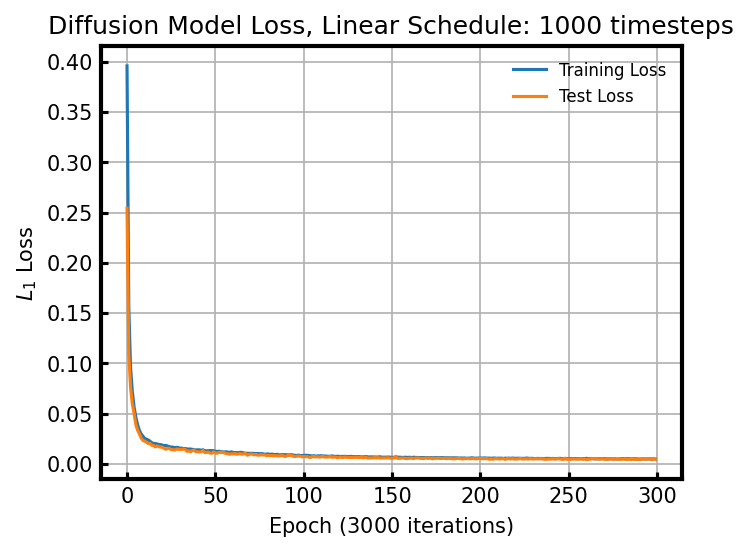

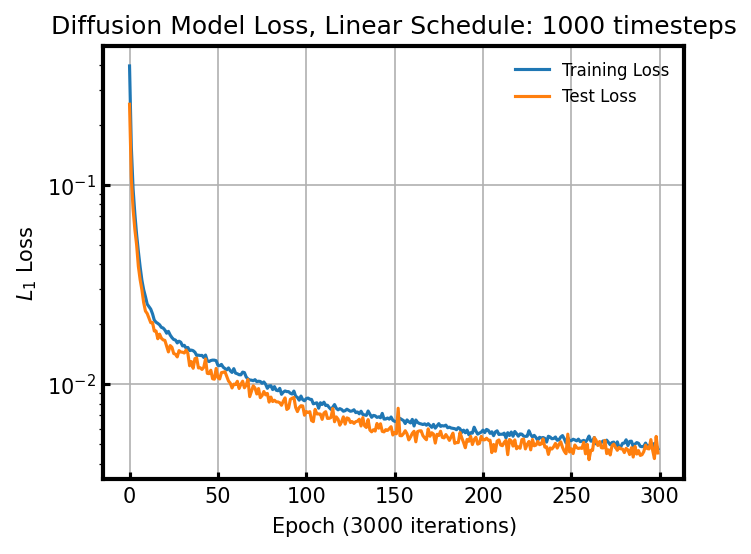

In [7]:
import numpy as np
test_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'validation_loss_epoch.txt'))
train_loss = np.loadtxt(os.path.join(diffusion_results_dir, 'loss_epoch.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Test Loss')

# plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')
plt.grid(which = 'major')
frame_tick()

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss[:], label = 'Test Loss')

# plt.plot(np.mean(test_loss[:24*70].reshape(-1, 24), axis=1), label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Diffusion Model Loss, Linear Schedule: 1000 timesteps')
plt.grid(which = 'major')
frame_tick()
plt.yscale('log')

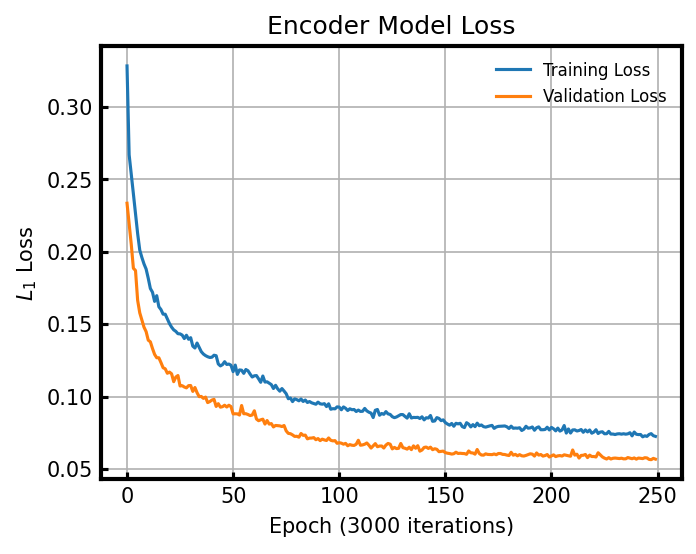

In [9]:
import numpy as np
test_loss = np.loadtxt(os.path.join(encoder_results_dir, 'test_loss.txt'))
train_loss = np.loadtxt(os.path.join(encoder_results_dir, 'train_loss.txt'))

plt.figure(figsize = np.array([4,3])*1.25, dpi = 150)

plt.plot(train_loss[:], label = 'Training Loss')
plt.plot(test_loss, label = "Validation Loss")

plt.xlabel(r'Epoch ($3000$ iterations)')
plt.ylabel(r'$L_1$ Loss')
legend()

plt.title('Encoder Model Loss')
plt.grid(which = 'major')
frame_tick()
plt.show()

In [12]:
from datasets.dataset import SimulationXZDataset
image_size = 80
channels = 1
batch_size =16
field_names = ['temperature']
train_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'train', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_09_30', return_info = True, field_names =  field_names, normalize = 'standardize')
test_dataset = SimulationXZDataset(downscale_method ='direct', split = 'test', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_09_30', return_info = True, field_names =  field_names, normalize = 'standardize')
dev_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'dev', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_09_30', return_info = True, field_names =  field_names, normalize = 'standardize')

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)


Using normalize method: ... standardize
Using specific fields,  ['temperature']
Processing dataset with 1 fields
Using normalize method: ... standardize
Using specific fields,  ['temperature']
Processing dataset with 1 fields
Using normalize method: ... standardize
Using specific fields,  ['temperature']
Processing dataset with 1 fields


In [25]:

os.environ['CUDA_VISIBLE_DEVICES']  = "5"
device = 'cuda'
criterion = torch.nn.L1Loss()
multi_field_results_dir = 'expanded_results'
lr_enc = load_encoder(encoder_results_dir, dataset = train_dataset)
model = load_diffusion(diffusion_results_dir, dataset = train_dataset)
batch_size = 2
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)


  0%|          | 0/2910 [00:00<?, ?it/s]

  1%|          | 34/2910 [00:38<54:50,  1.14s/it]  


KeyboardInterrupt: 

<Figure size 576x432 with 0 Axes>

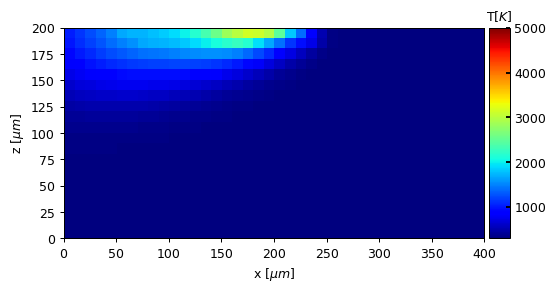

In [29]:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
last_power = ''
skip = 50
import time 
field_names = field_names#['vx', 'temperature', 'vy', 'vz', 'liqlabel']
verbose = False
for batch_idx, (res, hr, lr, upscaled_lr, info_full) in tqdm(enumerate(test_dataloader), total = len(test_dataloader), ):  
      
        for timesteps in [1000]:
        # timesteps = 2000
            for skips in [50]:
                oldtime = time.time()
                modeltype = 'RRDNss316l_standardize_test_temp_3_21'
                # print(hr.shape, lr.shape, upscaled_lr.shape, res.shape)
                info = info_full[0]
                input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
                # print(time.time()-oldtime)
                if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
                    timestep = 0
                else:
                    # print('timestep updated')
                    timestep += 1
                
                for field_idx, field_key in enumerate(field_names):
                    time_elapsed = time.time()-oldtime
                 
                    # print(info.shape, "info")
                    # print('power' + str(info[0].item()))# + 'vel' + str(info[1].item()))
                    folder = modeltype + 'saved_figures/{}/'.format(field_key)  + 'power' + str(info[0].item()) + 'vel' + str(info[1].item())
                    
                    os.makedirs(folder,exist_ok = True)

                    title  = os.path.join(folder,  'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))))
                    if verbose:
                        print(title, timestep)
                        print(input.shape, result.shape, target.shape)
                        print(time_elapsed, "elapsed time")
                    multifield_plot_images(input[0,:,:, :], result[0], target[0][:, :], field_idx = field_idx, field_key = field_key, timestep = timestep, split = 'Validation', modeltype =modeltype, timesteps = timesteps//skips, title =  title)
                    last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item()) 
                modeltype = 'Diffusionss316l_3_21' 
                # input, result_diffusion, target, xs, b = predict_ddim_diffusion(model, lr_enc, res[0:1], hr[0:1], lr[0:1], upscaled_lr[0:1],train_dataset,seq= None, timesteps = timesteps,skip = skips, schedule = 'linear')
                input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr,encoding = True,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
                for field_idx, field_key in enumerate(field_names):
                    info = info_full[0]
                    time_elapsed = time.time()-oldtime

                    # print(info.shape, "info")
                    # print('power' + str(info[0].item()))# + 'vel' + str(info[1].item()))
                    # if last_power != 'power' + str(info[0].item()) + 'vel' + str(info[1].item()):
                    #     timestep = 0
                    # else:
                    #     timestep += 1
                    
                    folder = modeltype +'saved_figures/{}/'.format(field_key)  + 'power' + str(info[0].item()) + 'vel' + str(info[1].item()) 

                    os.makedirs(folder,exist_ok = True)
                    title  = os.path.join(folder,  'batch_{:06}_'.format(batch_idx)+ 'time' + '{:07}'.format(int(np.round(info[2].item()*1e6))))
                    if verbose:
                        print(title, timestep)
                        print(input.shape, result.shape, target.shape)
                        print(time_elapsed, "elapsed time")
            # break
                    multifield_plot_images(input[0,:,:, :], result_diffusion[0], target[0][:, :], field_idx = field_idx, field_key = field_key, timestep = timestep, split = 'Validation', modeltype =modeltype, timesteps = timesteps//skips, title =  title)
                last_power = 'power' + str(info[0].item()) + 'vel' + str(info[1].item())  
